In [82]:
import pandas as pd

df = pd.read_csv(r"C:\Users\komal\OneDrive\Desktop\Healthcare_Project\health_data.csv")

print(df.head())


   Patient_ID   Name  Age  Gender    City       Disease   BP  Sugar_Level  \
0           1  Rohit   54  Female  Mumbai        Asthma  155           88   
1           2  Pooja   55  Female  Bhopal        Asthma  152          137   
2           3  Sneha   41  Female   Delhi        Asthma  123          141   
3           4  Rohit   48    Male  Indore  Hypertension  160          156   
4           5  Ankit   57    Male  Mumbai  Hypertension   96           90   

   Cholesterol   BMI  Visit_Date      Doctor       Hospital  Treatment_Cost  
0          193  27.1  05-11-2025   Dr. Gupta  Apollo Clinic           11497  
1          297  24.7  19-10-2025   Dr. Singh  Apollo Clinic           14279  
2          252  23.9  12-02-2026   Dr. Verma  City Hospital            8547  
3          190  27.9  03-01-2026   Dr. Verma  City Hospital           13414  
4          222  22.0  03-12-2025  Dr. Sharma  Apollo Clinic            7597  


In [58]:
print(df.isnull().sum())

Patient_ID        0
Name              0
Age               0
Gender            0
City              0
Disease           0
BP                0
Sugar_Level       0
Cholesterol       0
BMI               0
Visit_Date        0
Doctor            0
Hospital          0
Treatment_Cost    0
dtype: int64


In [61]:
df = df.drop_duplicates()

In [62]:
print(df["Patient_ID"].count())

200


In [63]:
print(df["Treatment_Cost"].mean())

10604.385


In [64]:
print(df["Disease"].value_counts())

Disease
Heart Disease    45
Asthma           44
Flu              44
Hypertension     38
Diabetes         29
Name: count, dtype: int64


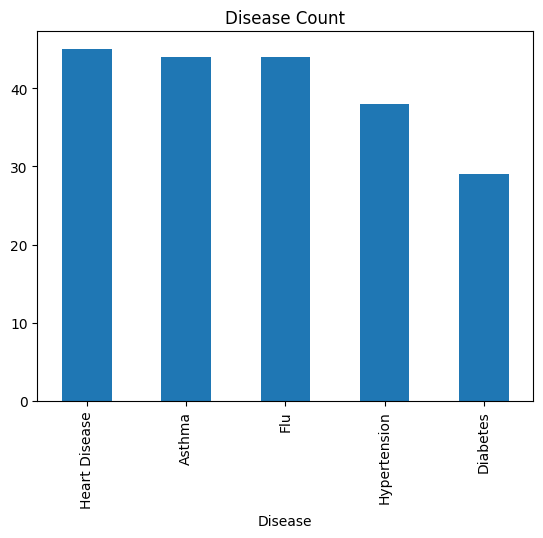

In [65]:
import matplotlib.pyplot as plt

df["Disease"].value_counts().plot(kind='bar')

plt.title("Disease Count")
plt.show()

In [66]:
print(df.columns)

Index(['Patient_ID', 'Name', 'Age', 'Gender', 'City', 'Disease', 'BP',
       'Sugar_Level', 'Cholesterol', 'BMI', 'Visit_Date', 'Doctor', 'Hospital',
       'Treatment_Cost'],
      dtype='object')


In [67]:
def calculate_risk(row):

    if (
        row['BP'] > 140 or
        row['Sugar_Level'] > 180 or
        row['Cholesterol'] > 240
    ):
        return "High Risk"

    elif (
        row['BP'] > 120 or
        row['Sugar_Level'] > 140 or
        row['Cholesterol'] > 200
    ):
        return "Medium Risk"

    else:
        return "Low Risk"


df['Risk_Level'] = df.apply(calculate_risk, axis=1)

print(df.head())

   Patient_ID   Name  Age  Gender    City       Disease   BP  Sugar_Level  \
0           1  Rohit   54  Female  Mumbai        Asthma  155           88   
1           2  Pooja   55  Female  Bhopal        Asthma  152          137   
2           3  Sneha   41  Female   Delhi        Asthma  123          141   
3           4  Rohit   48    Male  Indore  Hypertension  160          156   
4           5  Ankit   57    Male  Mumbai  Hypertension   96           90   

   Cholesterol   BMI  Visit_Date      Doctor       Hospital  Treatment_Cost  \
0          193  27.1  05-11-2025   Dr. Gupta  Apollo Clinic           11497   
1          297  24.7  19-10-2025   Dr. Singh  Apollo Clinic           14279   
2          252  23.9  12-02-2026   Dr. Verma  City Hospital            8547   
3          190  27.9  03-01-2026   Dr. Verma  City Hospital           13414   
4          222  22.0  03-12-2025  Dr. Sharma  Apollo Clinic            7597   

    Risk_Level  
0    High Risk  
1    High Risk  
2    High R

**Input Features**
Age
BMI
BP
Sugar_Level
Cholesterol


**Output**
Risk_Level

In [68]:
X= df[["Age","BMI","BP","Sugar_Level","Cholesterol"]]
y= df["Risk_Level"]

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [70]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [71]:
prediction = model.predict(X_test)

print(prediction)

['Medium Risk' 'High Risk' 'Medium Risk' 'High Risk' 'High Risk'
 'Medium Risk' 'High Risk' 'High Risk' 'High Risk' 'High Risk'
 'Medium Risk' 'High Risk' 'High Risk' 'Medium Risk' 'High Risk'
 'High Risk' 'High Risk' 'High Risk' 'High Risk' 'Medium Risk'
 'Medium Risk' 'High Risk' 'High Risk' 'Low Risk' 'Medium Risk'
 'Medium Risk' 'Medium Risk' 'High Risk' 'High Risk' 'High Risk'
 'High Risk' 'High Risk' 'High Risk' 'High Risk' 'High Risk' 'High Risk'
 'Medium Risk' 'High Risk' 'High Risk' 'Medium Risk']


In [72]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)

Accuracy: 0.95


In [81]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# Train model
model = RandomForestClassifier()

model.fit(X_train, y_train)

# Save model
joblib.dump(model, "risk_prediction_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


***Future Prediction***

**New Patient Prediction**

In [74]:
import pandas as pd

new_data = pd.DataFrame(
    [[25, 22.5, 150, 190, 250]],
    columns=["Age", "BMI", "BP", "Sugar_Level", "Cholesterol"]
)

prediction = model.predict(new_data)

print(prediction)

['High Risk']


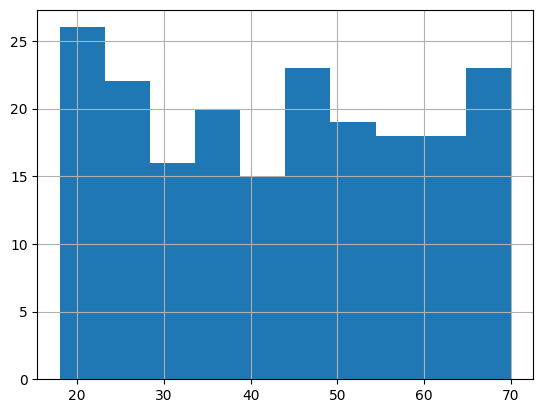

In [75]:
import matplotlib.pyplot as plt

df['Age'].hist()

plt.show()

In [76]:
highest_city = df.groupby("City")["Treatment_Cost"].sum().idxmax()

print("Highest Treatment Cost City:", highest_city)

Highest Treatment Cost City: Delhi


In [77]:
common_disease = df["Disease"].value_counts().idxmax()

print("Most Common Disease:", common_disease)

Most Common Disease: Heart Disease


In [78]:
avg_cost = df["Treatment_Cost"].mean()

print("Average Treatment Cost:", avg_cost)

Average Treatment Cost: 10604.385


In [79]:
high_risk = df[df["Risk_Level"] == "High Risk"]

print(high_risk.head())

   Patient_ID   Name  Age  Gender    City       Disease   BP  Sugar_Level  \
0           1  Rohit   54  Female  Mumbai        Asthma  155           88   
1           2  Pooja   55  Female  Bhopal        Asthma  152          137   
2           3  Sneha   41  Female   Delhi        Asthma  123          141   
3           4  Rohit   48    Male  Indore  Hypertension  160          156   
5           6  Sneha   39    Male    Pune  Hypertension  148          142   

   Cholesterol   BMI  Visit_Date     Doctor       Hospital  Treatment_Cost  \
0          193  27.1  05-11-2025  Dr. Gupta  Apollo Clinic           11497   
1          297  24.7  19-10-2025  Dr. Singh  Apollo Clinic           14279   
2          252  23.9  12-02-2026  Dr. Verma  City Hospital            8547   
3          190  27.9  03-01-2026  Dr. Verma  City Hospital           13414   
5          285  29.0  29-06-2025  Dr. Verma  Care Hospital            3028   

  Risk_Level  
0  High Risk  
1  High Risk  
2  High Risk  
3  High 

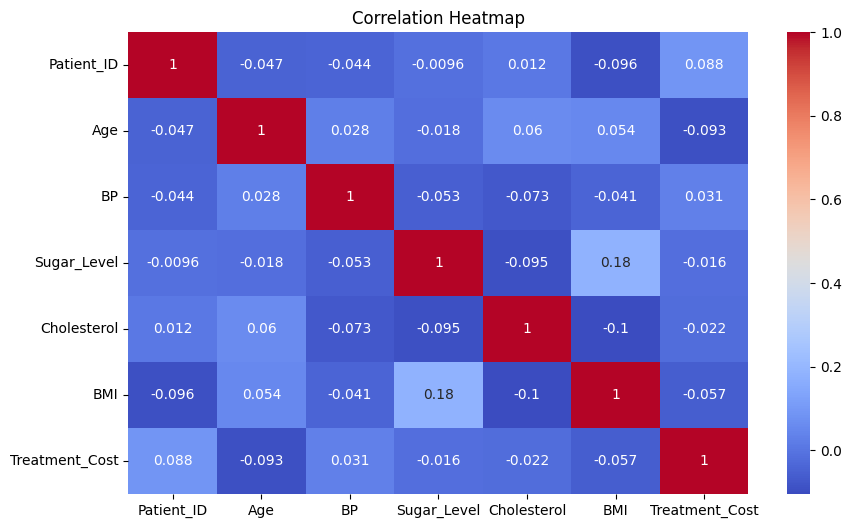

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Create figure size
plt.figure(figsize=(10, 6))

# Create heatmap
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

# Title
plt.title("Correlation Heatmap")

# Show graph
plt.show()

In [ ]:
pip install streamlit